<a href="https://colab.research.google.com/github/San4568GH/polymer-project/blob/main/Injection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

# URLs for the raw CSV files on GitHub
url_set_params = 'https://raw.githubusercontent.com/San4568GH/polymer-project/refs/heads/main/set_parameter_and_EM77_data.csv'
url_quality = 'https://raw.githubusercontent.com/San4568GH/polymer-project/refs/heads/main/quality_table_data.csv'

#  Load both CSV files from GitHub
set_params_df = pd.read_csv(url_set_params)
quality_df = pd.read_csv(url_quality, sep=';')

df = pd.merge(set_params_df, quality_df, on=['META_experiment', 'META_run'], how='inner')

# Define features and drop constant
xc = [c for c in df.columns if c.startswith('SET_') and c != 'SET_UP']
x = df[xc]

# Define targets (2 Objectives + 1 Constraint)
y_e = df['MEAS_KM_Energie Gesamt [Wh]']
y_t = df['MEAS_KM_Zyklus- Zeit Z [s]']
y_c = df['MEAS_KM_Masse- Polster [cm³]']

# Extract boundaries
bnds = x.agg(['min', 'max']).T
c_min, c_max = y_c.min(), y_c.max()

print(f"Data integrated. Target 1 (Energy): {y_e.min()} to {y_e.max()} Wh")
print(f"Target 2 (Cycle Time): {y_t.min()} to {y_t.max()} s")

Data integrated. Target 1 (Energy): 41.0 to 49.3 Wh
Target 2 (Cycle Time): 40.63 to 41.92 s


In [2]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_validate
from sklearn.pipeline import make_pipeline
import numpy as np
import pandas as pd
import copy

# 1. Define the 3 diverse surrogate models to evaluate
models_dict = {
    'RandomForest': RandomForestRegressor(n_estimators=100, random_state=42),
    'GradientBoosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'MLP_NeuralNet': make_pipeline(
        StandardScaler(),
        MLPRegressor(
            hidden_layer_sizes=(16, 8),
            max_iter=2000,
            random_state=42,
            early_stopping=True
        )
    )
}

# Store all results
results_table = []

# Helper function to run the tournament for a specific target
def get_best_surrogate(X_train, y_train, target_name):

    best_name = ""
    best_r2 = -float('inf')
    best_model = None

    # Test each model using 5-Fold Cross Validation
    for name, model in models_dict.items():

        cv_results = cross_validate(
            model,
            X_train,
            y_train.values.ravel(),
            cv=5,
            scoring='r2'
        )

        mean_r2 = np.mean(cv_results['test_score'])

        # Save result for table
        results_table.append({
            "Target": target_name,
            "Model": name,
            "Mean R2 Score": round(mean_r2, 4)
        })

        # Find best model
        if mean_r2 > best_r2:
            best_r2 = mean_r2
            best_name = name
            best_model = copy.deepcopy(model)

    # Train best model on full dataset
    best_model.fit(X_train, y_train.values.ravel())

    return best_model, best_name, best_r2

print("=== Running Surrogate Model Tournament ===\n")

# 2. Run tournament for each target
model_energy, name_e, r2_e = get_best_surrogate(x, y_e, "Energy")
model_time, name_t, r2_t = get_best_surrogate(x, y_t, "Cycle Time")
model_cushion, name_c, r2_c = get_best_surrogate(x, y_c, "Melt Cushion")

# 3. Create and display results table
results_df = pd.DataFrame(results_table)

print("\n=== 5-Fold Cross Validation R2 Results ===\n")
display(results_df)

# Optional: Show winners separately
winners_df = pd.DataFrame({
    "Target": ["Energy", "Cycle Time", "Melt Cushion"],
    "Best Model": [name_e, name_t, name_c],
    "Best R2 Score": [
        round(r2_e, 4),
        round(r2_t, 4),
        round(r2_c, 4)
    ]
})

print("\n=== Best Models ===\n")
display(winners_df)

print("Step 2 Complete: Best models are trained and ready for NSGA-II.")

=== Running Surrogate Model Tournament ===



/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(



=== 5-Fold Cross Validation R2 Results ===



,Target,Model,Mean R2 Score
0,Energy,RandomForest,-0.6621
1,Energy,GradientBoosting,-0.8477
2,Energy,MLP_NeuralNet,-99.9628
3,Cycle Time,RandomForest,0.7420
4,Cycle Time,GradientBoosting,0.7455
5,Cycle Time,MLP_NeuralNet,-527.5753
6,Melt Cushion,RandomForest,-1.3822
7,Melt Cushion,GradientBoosting,-1.3214
8,Melt Cushion,MLP_NeuralNet,-157.3560



=== Best Models ===



,Target,Best Model,Best R2 Score
0,Energy,RandomForest,-0.6621
1,Cycle Time,GradientBoosting,0.7455
2,Melt Cushion,GradientBoosting,-1.3214


Step 2 Complete: Best models are trained and ready for NSGA-II.


In [3]:
!pip install deap

import random
import pandas as pd
from deap import base, creator, tools

# 1. Define Multi-Objective Problem: Minimize Energy AND Minimize Cycle Time (-1.0, -1.0)
creator.create("FitnessMin", base.Fitness, weights=(-1.0, -1.0))
creator.create("Individual", list, fitness=creator.FitnessMin)

toolbox = base.Toolbox()

# 2. Define Attribute Generators based on input boundaries
bound_low = bnds['min'].values.astype(float)
bound_high = bnds['max'].values.astype(float)

# Prevent Division by Zero for constant parameters ---
epsilon = 1e-5
for i in range(len(bound_low)):
    if bound_low[i] == bound_high[i]:
        bound_low[i] -= epsilon
        bound_high[i] += epsilon

def create_individual():
    return creator.Individual([random.uniform(low, high) for low, high in zip(bound_low, bound_high)])

toolbox.register("individual", create_individual)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

# 3. Multi-Objective Fitness Function
def evaluate(individual):
    # Convert individual directly to a DataFrame with original column names
    X_input = pd.DataFrame([individual], columns=xc)

    # Predict objectives and constraint using the winning models from Step 2
    predicted_energy = model_energy.predict(X_input)[0]
    predicted_cycletime = model_time.predict(X_input)[0]
    predicted_cushion = model_cushion.predict(X_input)[0]

    # Apply Penalty if physical constraint (Melt Cushion) is violated
    if not (c_min <= predicted_cushion <= c_max):
        # Massive penalty applied to BOTH objectives
        return (predicted_energy + 10000.0, predicted_cycletime + 10000.0)

    return (predicted_energy, predicted_cycletime)

toolbox.register("evaluate", evaluate)

# 4. Define NSGA-II specific genetic operators
# These specific bounded operators ensure the mutations never exceed physical machine limits
toolbox.register("mate", tools.cxSimulatedBinaryBounded, low=bound_low.tolist(), up=bound_high.tolist(), eta=20.0)
toolbox.register("mutate", tools.mutPolynomialBounded, low=bound_low.tolist(), up=bound_high.tolist(), eta=20.0, indpb=1.0/len(xc))

# CRITICAL: Switch selection method to NSGA-II
toolbox.register("select", tools.selNSGA2)

print("Step 3 Complete: NSGA-II Multi-Objective problem and operators are configured.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.1/93.1 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 kB 31.0 MB/s eta 0:00:00
Step 3 Complete: NSGA-II Multi-Objective problem and operators are configured.


In [4]:
from deap import algorithms
import numpy as np

# 1. Initialize Population
population = toolbox.population(n=100)

# --- NEW: Seed the historical minimums into Generation 0 ---
best_energy_idx = y_e.idxmin()
best_time_idx = y_t.idxmin()

population[0] = creator.Individual(x.loc[best_energy_idx].values.tolist())
population[1] = creator.Individual(x.loc[best_time_idx].values.tolist())

# Track statistics for both objectives
stats = tools.Statistics(lambda ind: ind.fitness.values)
stats.register("min", np.min, axis=0)

print("--- Starting NSGA-II Multi-Objective Optimization ---")

# 2. Run the eaMuPlusLambda algorithm (The standard evolutionary loop for NSGA-II)
final_pop, logbook = algorithms.eaMuPlusLambda(
    population,
    toolbox,
    mu=100,
    lambda_=100,
    cxpb=0.9,
    mutpb=0.1,
    ngen=200,
    stats=stats,
    verbose=True  # Will print generation logs
)

# 3. Extract the Pareto Front (The set of non-dominated, optimal trade-off solutions)
pareto_front = tools.sortNondominated(final_pop, len(final_pop), first_front_only=True)[0]

print(f"\nOptimization Complete!")
print(f"Discovered {len(pareto_front)} optimal trade-off configurations on the Pareto Front.")

--- Starting NSGA-II Multi-Objective Optimization ---
gen	nevals	min                      
0  	100   	[41.74387262 40.63006431]
1  	100   	[41.74245595 40.63006431]
2  	100   	[41.74245595 40.63006431]
3  	100   	[41.74245595 40.63006431]
4  	100   	[41.74245595 40.63006431]
5  	100   	[41.74245595 40.63006431]
6  	100   	[41.74245595 40.63006431]
7  	100   	[41.74245595 40.63006431]
8  	100   	[41.74245595 40.63006431]
9  	100   	[41.74245595 40.63006431]
10 	100   	[41.74245595 40.63006431]
11 	100   	[41.74245595 40.63006431]
12 	100   	[41.74245595 40.63006431]
13 	100   	[41.74245595 40.63006431]
14 	100   	[41.74245595 40.63006431]
15 	100   	[41.74245595 40.63006431]
16 	100   	[41.74245595 40.63006431]
17 	100   	[41.74245595 40.63006431]
18 	100   	[41.74245595 40.63006431]
19 	100   	[41.74245595 40.63006431]
20 	100   	[41.74245595 40.63006431]
21 	100   	[41.74245595 40.63006431]
22 	100   	[41.74245595 40.63006431]
23 	100   	[41.74245595 40.63006431]
24 	100   	[41.742455

--- Step 5: Multi-Objective Visualization & Savings Report ---

              OPTIMIZATION SAVINGS REPORT
[BALANCED CONFIGURATION]
Energy Pred: 42.5138 Wh
  -> vs Original Average (45.5485 Wh): +6.66%
  -> vs Original Minimum (41.0000 Wh): -3.69%

Cycle Time Pred: 40.9133 s
  -> vs Original Average (41.2616 s):   +0.84%
  -> vs Original Minimum (40.6300 s):   -0.70%

[ABSOLUTE PARETO EXTREMES]
Best Theoretical Energy:     41.7425 Wh (-1.81% vs Min)
Best Theoretical Cycle Time: 40.6301 s (-0.00% vs Min)



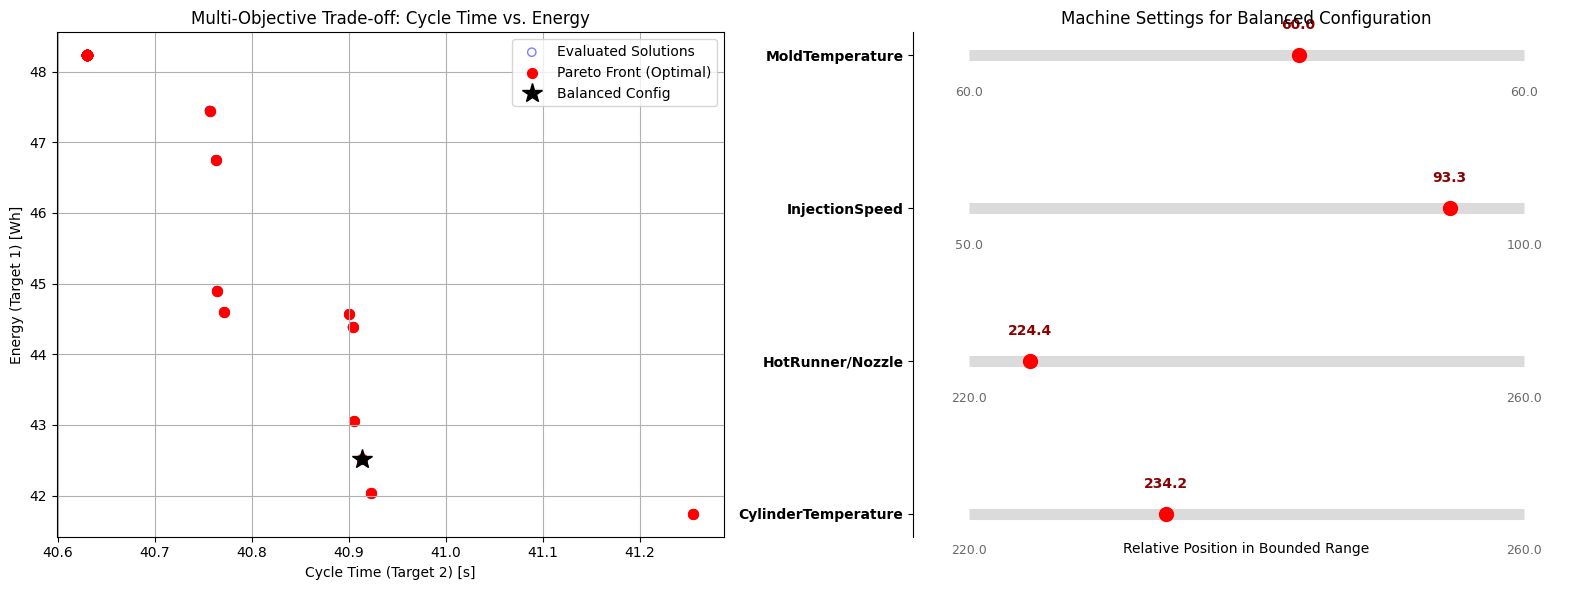


Balanced Machine Configuration (Raw Values):


,0
SET_CylinderTemperature,234.212539
SET_HotRunner/Nozzle,224.369979
SET_InjectionSpeed,93.260994
SET_MoldTemperature,60.000002


In [5]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("--- Step 5: Multi-Objective Visualization & Savings Report ---")

# 1. Extract objectives (Cycle Time & Energy) for all solutions and Pareto front
energy_all = [ind.fitness.values[0] for ind in final_pop]
time_all = [ind.fitness.values[1] for ind in final_pop]

energy_pareto = [ind.fitness.values[0] for ind in pareto_front]
time_pareto = [ind.fitness.values[1] for ind in pareto_front]

# # 2. Select a "Balanced" configuration from the Pareto Front
# sorted_front = sorted(pareto_front, key=lambda ind: ind.fitness.values[1])
# balanced_ind = sorted_front[len(sorted_front) // 2]

# 2. Select a True "Balanced" configuration using Euclidean distance to ideal point
# Normalize the objectives so time (40s) and energy (45Wh) are weighted equally
norm_energy = (np.array(energy_pareto) - min(energy_pareto)) / (max(energy_pareto) - min(energy_pareto) + 1e-9)
norm_time = (np.array(time_pareto) - min(time_pareto)) / (max(time_pareto) - min(time_pareto) + 1e-9)

# Calculate distance to the "Utopia Point" (0,0) which is perfect minimum time and energy
distances = np.sqrt(norm_energy**2 + norm_time**2)
best_balanced_idx = np.argmin(distances)

balanced_ind = pareto_front[best_balanced_idx]
balanced_energy = balanced_ind.fitness.values[0]
balanced_time = balanced_ind.fitness.values[1]

# ==========================================
# NEW: CALCULATE AND PRINT SAVINGS REPORT
# ==========================================
orig_e_min, orig_e_avg = y_e.min(), y_e.mean()
orig_t_min, orig_t_avg = y_t.min(), y_t.mean()

best_pareto_energy = min(energy_pareto)
best_pareto_time = min(time_pareto)

print("\n" + "="*55)
print("              OPTIMIZATION SAVINGS REPORT")
print("="*55)

print("[BALANCED CONFIGURATION]")
print(f"Energy Pred: {balanced_energy:.4f} Wh")
print(f"  -> vs Original Average ({orig_e_avg:.4f} Wh): {((orig_e_avg - balanced_energy)/orig_e_avg)*100:+.2f}%")
print(f"  -> vs Original Minimum ({orig_e_min:.4f} Wh): {((orig_e_min - balanced_energy)/orig_e_min)*100:+.2f}%")

print(f"\nCycle Time Pred: {balanced_time:.4f} s")
print(f"  -> vs Original Average ({orig_t_avg:.4f} s):   {((orig_t_avg - balanced_time)/orig_t_avg)*100:+.2f}%")
print(f"  -> vs Original Minimum ({orig_t_min:.4f} s):   {((orig_t_min - balanced_time)/orig_t_min)*100:+.2f}%")

print("\n[ABSOLUTE PARETO EXTREMES]")
print(f"Best Theoretical Energy:     {best_pareto_energy:.4f} Wh ({((orig_e_min - best_pareto_energy)/orig_e_min)*100:+.2f}% vs Min)")
print(f"Best Theoretical Cycle Time: {best_pareto_time:.4f} s ({((orig_t_min - best_pareto_time)/orig_t_min)*100:+.2f}% vs Min)")
print("="*55 + "\n")

# 3. Create the 1x2 Dashboard
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- PLOT 1: Pareto Front ---
axes[0].scatter(time_all, energy_all, facecolors='none', edgecolors='blue', alpha=0.5, label='Evaluated Solutions')
axes[0].scatter(time_pareto, energy_pareto, color='red', s=50, label='Pareto Front (Optimal)')
axes[0].plot(balanced_time, balanced_energy, 'k*', markersize=15, label='Balanced Config')

axes[0].set_title("Multi-Objective Trade-off: Cycle Time vs. Energy")
axes[0].set_xlabel("Cycle Time (Target 2) [s]")
axes[0].set_ylabel("Energy (Target 1) [Wh]")
axes[0].legend()
axes[0].grid(True)

# --- PLOT 2: Optimal Machine Settings (Horizontal Range Plot) ---
clean_labels = [col.replace('SET_', '') for col in xc]
normalized_params = (np.array(balanced_ind) - bound_low) / (bound_high - bound_low)
y_pos = np.arange(len(clean_labels))

axes[1].hlines(y_pos, 0, 1, color='lightgray', alpha=0.8, linewidth=8)
axes[1].plot(normalized_params, y_pos, 'ro', markersize=10, label='Optimal Setting')

for i, (val, norm_val) in enumerate(zip(balanced_ind, normalized_params)):
    axes[1].text(norm_val, i + 0.15, f"{val:.1f}", ha='center', va='bottom', fontsize=10, fontweight='bold', color='darkred')

for i, (min_v, max_v) in enumerate(zip(bound_low, bound_high)):
    axes[1].text(0, i - 0.2, f"{min_v:.1f}", ha='center', va='top', fontsize=9, color='dimgray')
    axes[1].text(1, i - 0.2, f"{max_v:.1f}", ha='center', va='top', fontsize=9, color='dimgray')

axes[1].set_yticks(y_pos)
axes[1].set_yticklabels(clean_labels, fontweight='bold')
axes[1].set_title("Machine Settings for Balanced Configuration")
axes[1].set_xlabel("Relative Position in Bounded Range")
axes[1].set_xlim(-0.1, 1.1)
axes[1].set_xticks([])
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].spines['bottom'].set_visible(False)

plt.tight_layout()
plt.show()

print("\nBalanced Machine Configuration (Raw Values):")
final_config_df = pd.Series(balanced_ind, index=xc)
display(final_config_df)